# Met Office PyEarthTools Machine Learning Demo Project

## Setup

In [1]:
import pyearthtools
from pyearthtools import data, pipeline

import site_archive_met_office

ROOT_DIRECTORIES: {'ERA5lowres': '/data/users/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


In [2]:
print(site_archive_met_office.get_root_directories())

{'ERA5lowres': '/data/users/dscop/weatherbench/5.625deg/', 'MOGLOBAL': '/data/users/dscop/pyearthtools_data/mo_global/', 'MOUKV': '/data/users/dscop/pyearthtools_data/mo_ukv/'}


## Create UKV PyEarthTools Data Accessor

In [3]:
ukv_accessor = pyearthtools.data.archive.MOUKV(['t2m', 'air_pressure_at_sea_level', 'u', 'v', 'specific_humidity' 'surface_altitude'])
ukv_accessor

MOUKV
	Description                    Met Office UKV (subset)
		 range                          '2018'
		 Documentation                  'https://www.metoffice.gov.uk/binaries/content/assets/metofficegovuk/pdf/data/ukv_model_data_sheet_2019.pdf'


	Initialisation                 
		 level_value                    None
		 variables                      ['t2m', 'air_pressure_at_sea_level', 'u', 'v', 'specific_humiditysurface_altitude']
	Transforms                     
		 StandardCoordinateNames        {'latitude': "['lat', 'Latitude', 'yt_ocean', 'yt']", 'longitude': "['lon', 'Longitude', 'xt_ocean', 'xt']", 'replacement_dictionary': 'None', 'time': "['Time']"}
		 Rename                         {'names': {'grid_latitude': "'latitude'", 'grid_longitude': "'longitude'"}}

In [4]:
sample_date = '2018-01-01T03'
ukv_sample_date = ukv_accessor[sample_date]
ukv_sample_date

<xarray.Dataset> Size: 14MB
Dimensions:                      (time: 1, latitude: 810, longitude: 621,
                                  grid_latitude_0: 811, grid_longitude_0: 621)
Coordinates:
  * latitude                     (latitude) float32 3kB -3.771 -3.757 ... 7.151
  * longitude                    (longitude) float64 5kB 354.9 354.9 ... 363.3
    forecast_period              timedelta64[ns] 8B ...
    forecast_reference_time      datetime64[ns] 8B ...
  * time                         (time) datetime64[ns] 8B 2018-01-01T03:00:00
    height                       float64 8B ...
    forecast_period_0            timedelta64[ns] 8B ...
    time_0                       datetime64[ns] 8B ...
  * grid_latitude_0              (grid_latitude_0) float32 3kB -3.777 ... 7.158
  * grid_longitude_0             (grid_longitude_0) float64 5kB 354.9 ... 363.3
    height_0                     float64 8B ...
Data variables:
    air_pressure_at_sea_level    (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    rotated_latitude_longitude   (time) int32 4B -2147483647
    air_temperature              (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    specific_humidity            (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    surface_altitude             (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    toa_outgoing_shortwave_flux  (time, latitude, longitude) float32 2MB dask.array<chunksize=(1, 810, 621), meta=np.ndarray>
    x_wind                       (time, grid_latitude_0, grid_longitude_0) float32 2MB dask.array<chunksize=(1, 811, 621), meta=np.ndarray>
    y_wind                       (time, grid_latitude_0, grid_longitude_0) float32 2MB dask.array<chunksize=(1, 811, 621), meta=np.ndarray>
Attributes:
    source:       Data from Met Office Unified Model
    um_version:   10.6
    Conventions:  CF-1.7

## Visualise the data

In [5]:
variables = ['air_temperature', 'air_pressure_at_sea_level', 'x_wind', 'y_wind', 'specific_humidity', 'surface_altitude']

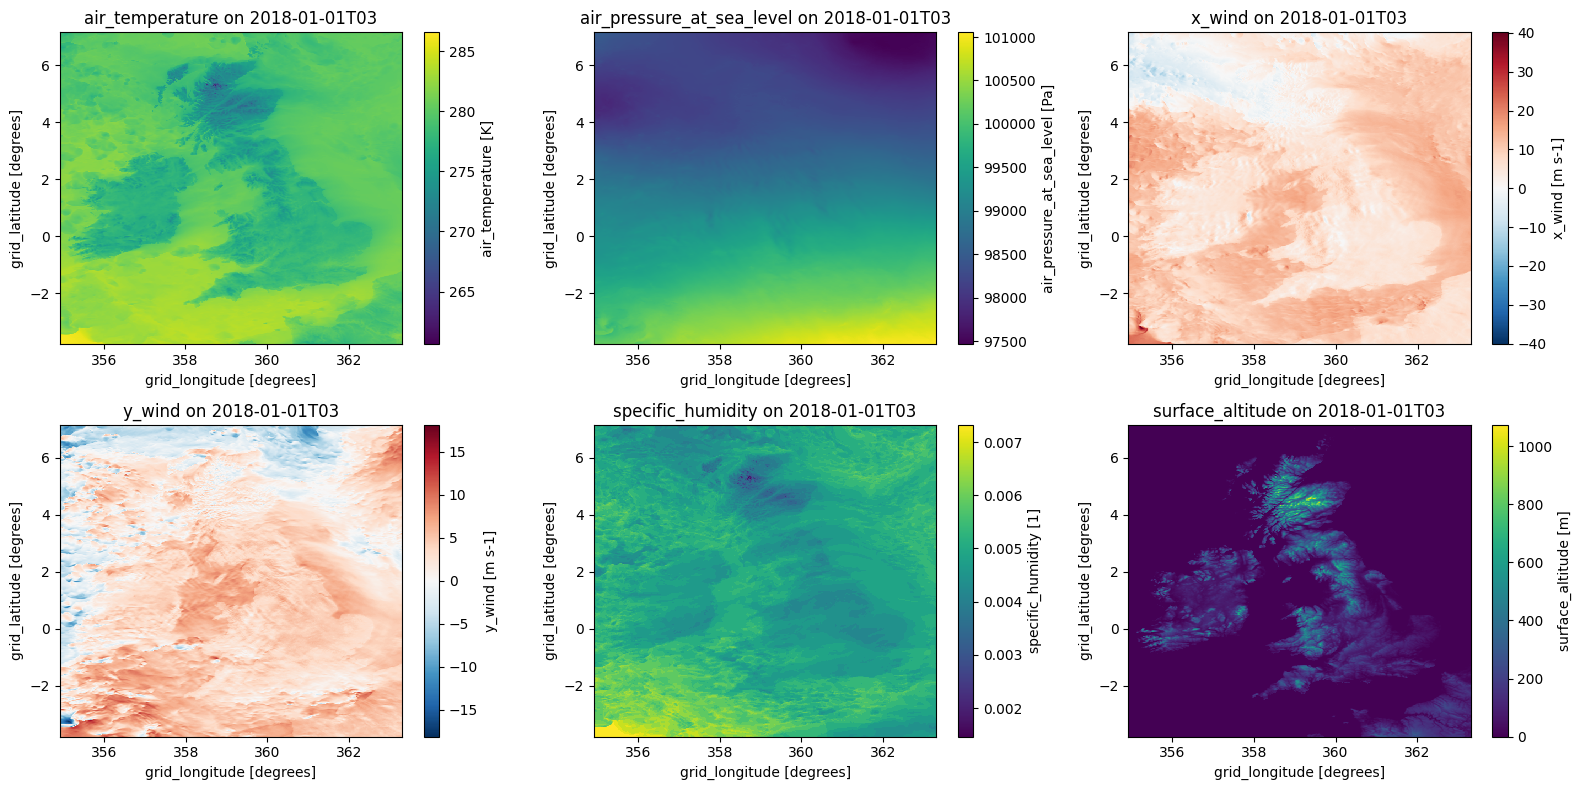

In [6]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(2, 3, figsize=(16, 8))

for ax, var in zip(axs.flat, variables):
    ukv_sample_date[var].plot(ax=ax)
    ax.set_title(f'{var} on {sample_date}')

plt.tight_layout()
plt.show()

## Data Processing Pipeline

Fontconfig error: Cannot load default config file: No such file: (null)


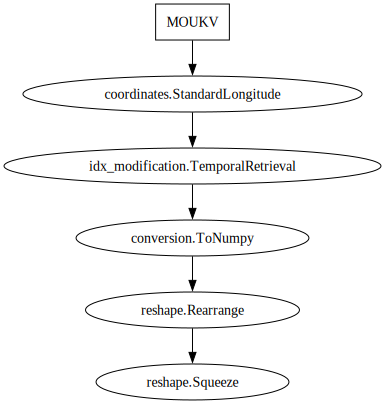

In [ ]:
import pyearthtools.pipeline


ukv_data_pipeline = pyearthtools.pipeline.Pipeline(
    ukv_accessor,
    pyearthtools.data.transforms.coordinates.StandardLongitude(type="-180-180"),
    
    # Uncomment the line below if working with multi-level data
    # pyearthtools.pipeline.operations.xarray.reshape.CoordinateFlatten("level"),    
    
    pyearthtools.pipeline.modifications.TemporalRetrieval(
        concat=True, samples=((0, 4), (6, 1)) # Input = 1 sample T=0 hours. Target = T+6
    ),    
    pyearthtools.pipeline.operations.xarray.conversion.ToNumpy(),
    pyearthtools.pipeline.operations.numpy.reshape.Rearrange('c t h w -> t c h w'), # channel time height width -> time channel height width
    pyearthtools.pipeline.operations.numpy.reshape.Squeeze(axis=0),

)

ukv_data_pipeline

### Scaling
Becuase our data was split into training and target data inside the pipeline above using the TemporalRetrieval method, we need to use the pipeline to access and scale just the training data.

In [43]:
ukv_training_samples = ukv_data_pipeline[sample_date]

print("Input sample:", ukv_training_samples[0])


DataNotFoundError: Data with args: (Petdt('2018-01-01T04'),) could not be found.

#### Test the pipeline

In [9]:
# Let's provide the ukv_data_pipeline a sample date. 
sample_pipeline_date = ukv_data_pipeline['2018-01-01T03']

# Print the Input and Target samples generated by the pipeline
print("Input sample:", sample_pipeline_date[0].time.data)
print("Target sample:", sample_pipeline_date[1].time.data)

TypeError: len() of unsized object